# Laboratorio 3 - Sesión 10
## Interpretación del entrenamiento de una red neuronal industrial

**Modalidad:** trabajo grupal  
**Entrega:** un notebook por grupo  
**Trabajo del grupo:** ejecutar, observar, discutir e interpretar  
**Código:** completo y provisto por el docente  
**Evidencia:** resultados de la ejecución y respuestas grupales en Markdown  
**Regla central:** el modelo y el umbral se seleccionan con validation; test se abre una sola vez.

## Cómo trabajar

1. Ejecuten las celdas en orden, sin modificar el código.
2. No dividan las preguntas entre integrantes. Todos deben observar la evidencia y proponer una interpretación.
3. En cada bloque: una persona lee la salida, otra identifica la evidencia, otra cuestiona la conclusión y otra registra el acuerdo. Roten los roles.
4. Después de discutir, respondan en la celda **Respuesta del grupo**.
5. Sustenten sus respuestas con valores, tablas o gráficas producidas por el notebook.
6. No utilicen test para cambiar arquitectura, épocas, regularización o umbral.
7. Si necesitan repetir todo el laboratorio, reinicien el entorno y ejecuten desde el inicio.
8. Renombren el archivo como `GRUPO_N_M3_LAB3.ipynb`.

> Este laboratorio evalúa interpretación y construcción de acuerdos. No se califica la escritura de código.

## Identificación del grupo

**Grupo:**  
**Integrantes:**  
**Responsable de subir la entrega:**  

### Acuerdo de participación

- Todos los integrantes intervienen en los ocho bloques de interpretación.
- Los roles de facilitación, lectura de evidencia, cuestionamiento y relatoría se rotan.
- La respuesta escrita representa el consenso del grupo, no la suma de respuestas individuales.

## 0. Entorno y reproducibilidad

La siguiente celda prepara todas las bibliotecas y fija la semilla. Ejecútenla sin modificarla.

In [1]:
# Código provisto: entorno de trabajo
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, average_precision_score
)

try:
    import tensorflow as tf
    from tensorflow import keras
except ImportError as exc:
    raise ImportError(
        "Este laboratorio requiere TensorFlow/Keras. Ejecútelo en Google Colab."
    ) from exc

sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
# Código provisto: reproducibilidad y costos didácticos
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# Estos costos sirven para comparar decisiones; no representan valores financieros reales.
COSTO_FN = 10
COSTO_FP = 1

print(f"Costo didáctico de un falso negativo: {COSTO_FN}")
print(f"Costo didáctico de un falso positivo: {COSTO_FP}")

Costo didáctico de un falso negativo: 10
Costo didáctico de un falso positivo: 1


## 1. Dataset industrial didáctico

Cada fila representa una lectura operativa de un activo industrial. El objetivo `riesgo_falla` vale 1 cuando se simula una condición de riesgo y 0 en caso contrario.

El dataset se genera dentro del notebook y no contiene datos personales ni información real de una empresa.

Dimensiones: (4000, 7)


,temperatura_c,presion_bar,vibracion_mm_s,carga_pct,corriente_a,horas_desde_mantenimiento,riesgo_falla
0,74.742454,6.427884,2.530888,52.949091,42.781255,134.033088,0
1,62.640143,7.005697,3.697739,75.839206,56.185443,134.829691,0
2,78.754061,6.445989,3.666017,48.124491,49.865650,259.630250,0
3,80.465082,8.214948,1.820399,70.585667,78.840988,300.063661,0
4,54.440683,7.486809,2.386779,85.101301,70.524524,437.232074,0


,filas
riesgo_falla,
0,3707
1,293


,proporción
riesgo_falla,
0,0.92675
1,0.07325


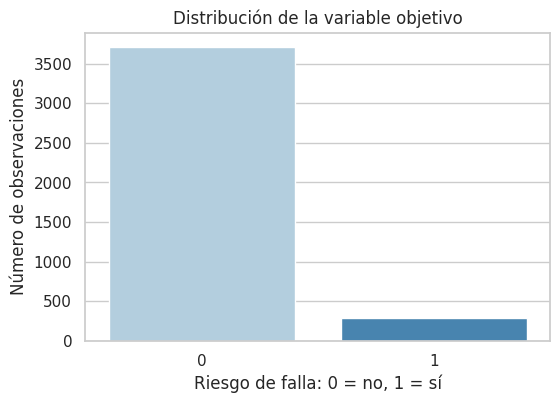

In [3]:
# Código provisto: dataset industrial sintético y reproducible
rng = np.random.default_rng(SEED)
n = 4000

temperatura = rng.normal(72, 9, n).clip(35, 120)
presion = rng.normal(6.2, 0.9, n).clip(2.5, 10.5)
vibracion = rng.lognormal(np.log(2.2), 0.42, n).clip(0.4, 10)
carga = rng.uniform(35, 100, n)
horas_mant = rng.gamma(2.2, 160, n).clip(0, 1400)
corriente = (
    18 + 0.62 * carga + 0.30 * (temperatura - 70) + rng.normal(0, 5, n)
).clip(10, 110)

# Relación no lineal con ruido controlado.
score = (
    -3.6
    + 0.055 * (temperatura - 70)
    + 0.65 * (vibracion - 2.2)
    + 0.025 * (carga - 70)
    + 0.0028 * (horas_mant - 300)
    + 0.015 * np.maximum(temperatura - 82, 0) * np.maximum(vibracion - 4, 0)
    + rng.normal(0, 0.65, n)
)
prob_falla = 1 / (1 + np.exp(-score))
riesgo_falla = rng.binomial(1, prob_falla)

df = pd.DataFrame({
    "temperatura_c": temperatura,
    "presion_bar": presion,
    "vibracion_mm_s": vibracion,
    "carga_pct": carga,
    "corriente_a": corriente,
    "horas_desde_mantenimiento": horas_mant,
    "riesgo_falla": riesgo_falla,
})

FEATURES = [
    "temperatura_c", "presion_bar", "vibracion_mm_s",
    "carga_pct", "corriente_a", "horas_desde_mantenimiento"
]
TARGET = "riesgo_falla"

print("Dimensiones:", df.shape)
display(df.head())
display(df[TARGET].value_counts().rename("filas").to_frame())
display(df[TARGET].value_counts(normalize=True).rename("proporción").to_frame())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, hue=TARGET, palette="Blues", legend=False, ax=ax)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Riesgo de falla: 0 = no, 1 = sí")
ax.set_ylabel("Número de observaciones")
plt.show()

In [4]:
# Código provisto: auditoría mínima de la Capa Silver didáctica
assert df[FEATURES + [TARGET]].notna().all().all()
assert np.isfinite(df[FEATURES].to_numpy()).all()
assert set(df[TARGET].unique()).issubset({0, 1})

display(df[FEATURES].describe().T)
print("Auditoría superada: sin faltantes, infinitos ni etiquetas fuera de 0/1.")

,count,mean,std,min,25%,50%,75%,max
temperatura_c,4000.0,71.824438,8.998715,39.164285,65.753396,71.992427,77.737380,100.609683
presion_bar,4000.0,6.199938,0.904204,2.500000,5.604516,6.181734,6.795481,9.308642
vibracion_mm_s,4000.0,2.392611,1.073293,0.499668,1.650568,2.178107,2.897063,10.000000
carga_pct,4000.0,67.689958,18.779725,35.003291,51.167122,67.984533,83.874111,99.996572
corriente_a,4000.0,60.668725,13.015476,26.016207,50.453919,60.891345,71.067571,97.206476
horas_desde_mantenimiento,4000.0,359.602102,238.783174,3.275325,180.466854,308.665718,478.621239,1400.000000


Auditoría superada: sin faltantes, infinitos ni etiquetas fuera de 0/1.


### Interpretación 1 - Población y variable objetivo

1. ¿Qué representa una fila y cuál es la variable que se quiere predecir?
2. ¿La clase 1 es mayoritaria, minoritaria o aproximadamente equilibrada? Citen la proporción observada.
3. ¿Por qué la accuracy podría ser insuficiente para evaluar este problema?

### Respuesta del grupo

**Respuesta 1.** Una fila representa una lectura operativa de un activo industrial, descrita por temperatura, presión, vibración, carga, corriente y horas desde el mantenimiento. La variable que se quiere predecir es `riesgo_falla`: vale 1 cuando existe una condición de riesgo y 0 cuando no existe.

**Respuesta 2.** La clase 1 es minoritaria. Se observaron 293 casos de riesgo entre 4.000 filas, equivalentes al 7,325 %, mientras que la clase 0 representa el 92,675 %.

**Respuesta 3.** La *accuracy* puede ser engañosa debido al desbalance. Un modelo que predijera siempre “sin riesgo” alcanzaría aproximadamente 92,7 % de exactitud, pero no detectaría ninguna falla. Por ello también deben analizarse *recall*, *precision*, PR-AUC, falsos negativos y el costo de los errores.

## 2. Partición tripartita

El código separa los datos en 60% para entrenamiento, 20% para validation y 20% para test. La estratificación conserva una proporción de eventos comparable.

In [5]:
# Código provisto: separación 60/20/20 estratificada
X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=SEED,
)

# Contabilidad y separación de índices.
assert len(X_train) + len(X_val) + len(X_test) == len(X)
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)

resumen_particion = pd.DataFrame({
    "filas": [len(X_train), len(X_val), len(X_test)],
    "porcentaje": [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
    "tasa_evento": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "validation", "test"])

display(resumen_particion.style.format({"porcentaje": "{:.1%}", "tasa_evento": "{:.2%}"}))

,filas,porcentaje,tasa_evento
train,2400,60.0%,7.33%
validation,800,20.0%,7.25%
test,800,20.0%,7.38%


### Interpretación 2 - Función de cada conjunto

1. ¿Las tasas de evento de train, validation y test son suficientemente parecidas? Citen los valores.
2. Expliquen con sus palabras para qué se usa cada conjunto.
3. ¿Qué riesgo aparecería si se consultara test para elegir arquitectura o umbral?

### Respuesta del grupo

**Respuesta 1.** Sí. Las tasas de evento son suficientemente parecidas: 7,33 % en *train*, 7,25 % en *validation* y 7,38 % en *test*. Esto confirma que la estratificación conservó una proporción comparable de eventos.

**Respuesta 2.** *Train* (2.400 filas) se usa para aprender los parámetros de la red y ajustar el escalador. *Validation* (800 filas) sirve para comparar modelos, observar la generalización y seleccionar el umbral. *Test* (800 filas) queda reservado para una evaluación final e imparcial.

**Respuesta 3.** Si se consultara *test* para escoger la arquitectura o el umbral, las decisiones se adaptarían indirectamente a esos datos. Esto produciría fuga de información y una estimación demasiado optimista del desempeño en datos realmente nuevos.

## 3. Escalamiento sin fuga de información

El escalador aprende sus parámetros únicamente con train. Después aplica esos mismos parámetros a validation y test.

In [6]:
# Código provisto: StandardScaler ajustado solo con train
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

assert np.isfinite(X_train_s).all()
assert np.isfinite(X_val_s).all()
assert np.isfinite(X_test_s).all()

resumen_escalado = pd.DataFrame({
    "media_train": X_train_s.mean(axis=0),
    "desv_train": X_train_s.std(axis=0),
    "media_validation": X_val_s.mean(axis=0),
    "media_test": X_test_s.mean(axis=0),
}, index=FEATURES)

display(resumen_escalado.round(3))

,media_train,desv_train,media_validation,media_test
temperatura_c,-0.0,1.0,-0.025,-0.020
presion_bar,-0.0,1.0,0.004,0.058
vibracion_mm_s,0.0,1.0,-0.016,-0.025
carga_pct,0.0,1.0,0.011,0.031
corriente_a,0.0,1.0,0.019,0.023
horas_desde_mantenimiento,0.0,1.0,-0.056,0.007


### Interpretación 3 - Escalamiento y fuga

1. ¿Qué evidencia muestra que train quedó aproximadamente centrado y escalado?
2. ¿Por qué las medias de validation y test no tienen que ser exactamente cero?
3. ¿Cómo se produciría fuga de información si el escalador se ajustara usando todas las filas?

### Respuesta del grupo

**Respuesta 1.** Todas las variables de *train* presentan una media aproximada de 0,000 y una desviación estándar de 1,000. Esta evidencia confirma que el conjunto quedó centrado y escalado.

**Respuesta 2.** Las medias de *validation* oscilan entre -0,056 y 0,019, y las de *test* entre -0,025 y 0,058. No tienen que ser exactamente cero porque son muestras distintas y se transformaron usando únicamente los parámetros aprendidos con *train*.

**Respuesta 3.** Si el escalador se ajustara con todas las filas, las medias y desviaciones de *validation* y *test* influirían en la transformación usada para entrenar. El modelo recibiría información de conjuntos futuros, causando fuga de información y una evaluación artificialmente favorable.

## 4. Funciones de evaluación

Estas funciones calculan las métricas, buscan el umbral de menor costo didáctico y generan las gráficas. Ejecuten la celda sin modificarla.

In [7]:
# Código provisto: funciones de evaluación y visualización
def metricas_binarias(y_true, prob, umbral=0.5):
    prob = np.asarray(prob).ravel()
    pred = (prob >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "umbral": float(umbral),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, prob),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "costo_unidades": int(COSTO_FN * fn + COSTO_FP * fp),
    }


def buscar_umbral_costo(y_true, prob, costo_fn=COSTO_FN, costo_fp=COSTO_FP):
    prob = np.asarray(prob).ravel()
    filas = []
    for umbral in np.linspace(0.02, 0.80, 157):
        pred = (prob >= umbral).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        filas.append({
            "umbral": float(umbral),
            "costo_unidades": int(costo_fn * fn + costo_fp * fp),
            "recall": recall_score(y_true, pred, zero_division=0),
            "precision": precision_score(y_true, pred, zero_division=0),
            "fp": int(fp),
            "fn": int(fn),
        })
    tabla = pd.DataFrame(filas)
    mejor = tabla.sort_values(
        ["costo_unidades", "recall"], ascending=[True, False]
    ).iloc[0]
    return float(mejor["umbral"]), tabla


def graficar_historial(history, titulo):
    hist = pd.DataFrame(history.history)
    ax = hist[["loss", "val_loss"]].plot(figsize=(8, 4), linewidth=2)
    ax.set_title(titulo)
    ax.set_xlabel("Época")
    ax.set_ylabel("Binary cross-entropy")
    ax.legend(["train_loss", "val_loss"])
    plt.show()


def graficar_matriz(y_true, prob, umbral, titulo):
    pred = (np.asarray(prob).ravel() >= umbral).astype(int)
    matriz = confusion_matrix(y_true, pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(
        matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Sin riesgo", "Riesgo"],
        yticklabels=["Sin riesgo", "Riesgo"], ax=ax,
    )
    ax.set_title(titulo)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Realidad")
    plt.show()

## 5. Baseline

El baseline ignora las variables X y usa únicamente la proporción observada de cada clase. Sirve para comprobar si la red neuronal aporta valor real.

In [8]:
# Código provisto: DummyClassifier como baseline
dummy = DummyClassifier(strategy="prior", random_state=SEED)
dummy.fit(X_train_s, y_train)

prob_dummy_val = dummy.predict_proba(X_val_s)[:, 1]
resultado_dummy_val = metricas_binarias(y_val, prob_dummy_val, umbral=0.5)

display(
    pd.DataFrame([resultado_dummy_val], index=["DummyClassifier - validation"])
    .round(3)
)

,umbral,accuracy,precision,recall,f1,pr_auc,tn,fp,fn,tp,costo_unidades
DummyClassifier - validation,0.5,0.928,0.0,0.0,0.0,0.072,742,0,58,0,580


### Interpretación 4 - Baseline y desbalance

1. ¿Cómo puede el baseline obtener una accuracy aparentemente aceptable sin detectar adecuadamente la clase de interés?
2. Comparen accuracy, recall y PR-AUC. ¿Qué revela cada una?
3. ¿Qué debería superar una MLP para justificar su uso frente a este baseline?

### Respuesta del grupo

**Respuesta 1.** El `DummyClassifier` usa la proporción previa y, con umbral 0,5, clasifica todas las filas como clase 0. Así obtiene una *accuracy* de 0,928 porque la clase 0 es mayoritaria, pero no detecta ninguno de los 58 eventos: presenta 58 FN, 0 TP y *recall* de 0,000.

**Respuesta 2.** La *accuracy* de 0,928 refleja los aciertos totales y está dominada por la clase mayoritaria. El *recall* de 0,000 revela que no se identifica ningún riesgo. La PR-AUC de 0,072 apenas corresponde a la prevalencia de la clase positiva y muestra una capacidad discriminativa muy baja.

**Respuesta 3.** Para justificar su uso, una MLP debe aumentar claramente el *recall* y la PR-AUC y, según los costos establecidos, reducir el costo total frente a las 580 unidades del baseline.

## 6. MLP inicial y curvas de aprendizaje

La primera red tiene tres capas ocultas. El notebook la entrena durante 60 épocas y presenta las curvas de pérdida de train y validation.

Épocas ejecutadas: 60
Mejor val_loss: 0.2151
Época del mejor val_loss: 8


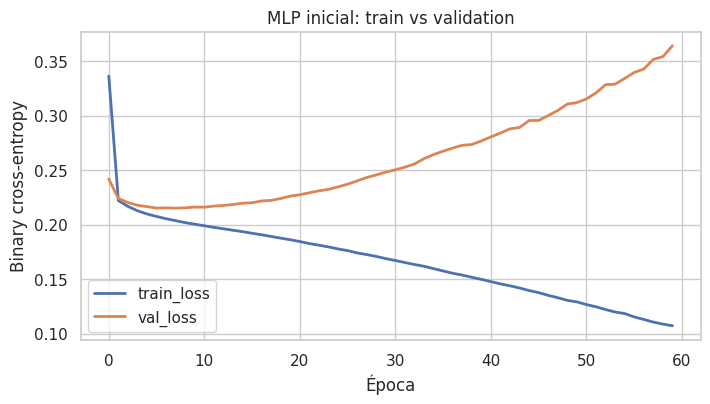

In [9]:
# Código provisto: MLP inicial 128 -> 64 -> 32 -> 1
def crear_mlp_inicial(n_features):
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ], name="mlp_inicial")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model


mlp_inicial = crear_mlp_inicial(X_train_s.shape[1])
history_inicial = mlp_inicial.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=60,
    batch_size=32,
    verbose=0,
)

hist_inicial = pd.DataFrame(history_inicial.history)
print("Épocas ejecutadas:", len(hist_inicial))
print("Mejor val_loss:", round(hist_inicial["val_loss"].min(), 4))
print("Época del mejor val_loss:", int(hist_inicial["val_loss"].idxmin() + 1))
graficar_historial(history_inicial, "MLP inicial: train vs validation")

### Interpretación 5 - Diagnóstico de la MLP inicial

1. ¿En qué época se observa el menor `val_loss`?
2. ¿Qué ocurre con `train_loss` y `val_loss` después de ese punto?
3. Clasifiquen el entrenamiento como estable, subajustado o sobreajustado. Justifiquen con la gráfica.

### Respuesta del grupo

**Respuesta 1.** El menor `val_loss` fue 0,2151 y se observó en la época 8.

**Respuesta 2.** Después de ese punto, `train_loss` continúa disminuyendo, mientras `val_loss` deja de mejorar y presenta oscilaciones o una tendencia ascendente. En consecuencia, la brecha entre ambas curvas aumenta.

**Respuesta 3.** El entrenamiento se clasifica como sobreajustado. La red aprende cada vez mejor los datos de entrenamiento, pero esa mejora no se transfiere a *validation*. No parece un caso de subajuste ni de inestabilidad general, porque la pérdida de entrenamiento sí disminuye de forma sostenida. La separación posterior a la época 8 indica que conservar los pesos de la época 60 no sería lo más conveniente para generalizar.

## 7. MLP regularizada

La segunda red reduce su capacidad e incorpora regularización L2, Dropout y EarlyStopping. El propósito es mejorar la generalización, no hacer la red más compleja.

Épocas ejecutadas: 52
Mejor val_loss: 0.2165
Época del mejor val_loss: 47


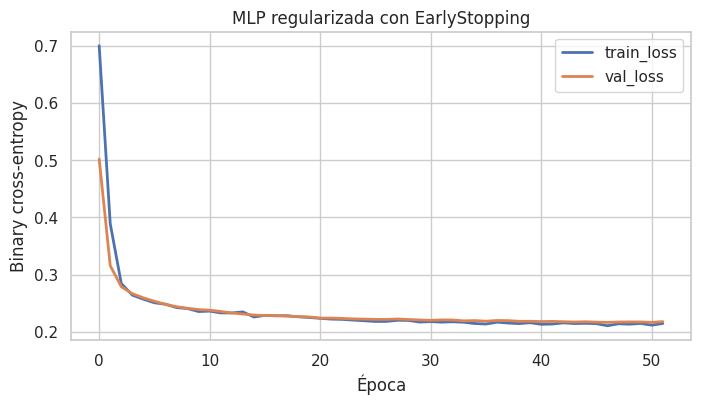

In [10]:
# Código provisto: MLP regularizada 32 -> Dropout -> 16 -> 1
def crear_mlp_regularizada(n_features):
    regularizador = keras.regularizers.l2(0.001)
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        keras.layers.Dense(
            32, activation="relu", kernel_regularizer=regularizador
        ),
        keras.layers.Dropout(0.20),
        keras.layers.Dense(
            16, activation="relu", kernel_regularizer=regularizador
        ),
        keras.layers.Dense(1, activation="sigmoid"),
    ], name="mlp_regularizada")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model


early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    min_delta=1e-3,
    patience=8,
    restore_best_weights=True,
)

mlp_regularizada = crear_mlp_regularizada(X_train_s.shape[1])
history_regularizada = mlp_regularizada.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)

hist_regularizada = pd.DataFrame(history_regularizada.history)
print("Épocas ejecutadas:", len(hist_regularizada))
print("Mejor val_loss:", round(hist_regularizada["val_loss"].min(), 4))
print("Época del mejor val_loss:", int(hist_regularizada["val_loss"].idxmin() + 1))
graficar_historial(
    history_regularizada,
    "MLP regularizada con EarlyStopping",
)

### Interpretación 6 - Comparación de las curvas

1. ¿La brecha entre train y validation disminuyó respecto a la MLP inicial?
2. ¿EarlyStopping detuvo el entrenamiento antes de 100 épocas? ¿Qué significa?
3. ¿Qué modelo parece generalizar mejor según las curvas? Citen evidencia concreta.

### Respuesta del grupo

**Respuesta 1.** Sí. La MLP regularizada muestra una brecha menor y una evolución más cercana entre las pérdidas de *train* y *validation* que la MLP inicial. Esto es coherente con su menor capacidad, la regularización L2 y el `Dropout`.

**Respuesta 2.** Sí. `EarlyStopping` detuvo el entrenamiento en 52 épocas, antes del máximo de 100. Esto significa que `val_loss` dejó de mejorar lo suficiente durante el periodo de paciencia; luego se restauraron los mejores pesos.

**Respuesta 3.** La MLP regularizada parece generalizar mejor según las curvas, porque mantiene un comportamiento más estable y alcanza su mejor `val_loss` de 0,2165 en la época 47. La MLP inicial logró 0,2151 en la época 8, pero después presentó una separación creciente entre entrenamiento y validación.

## 8. Selección del modelo y del umbral con validation

Cada falso negativo cuesta 10 unidades y cada falso positivo cuesta 1. El código busca el umbral de menor costo en validation y selecciona la MLP con mejor resultado bajo ese criterio.

,umbral,accuracy,precision,recall,f1,pr_auc,fp,fn,costo_unidades
modelo,,,,,,,,,
DummyClassifier,0.500,0.928,0.000,0.000,0.000,0.072,0,58,580
MLP inicial,0.025,0.721,0.140,0.552,0.223,0.207,197,26,457
MLP regularizada,0.080,0.809,0.232,0.707,0.349,0.309,136,17,306


Modelo congelado: MLP regularizada
Umbral congelado: 0.08


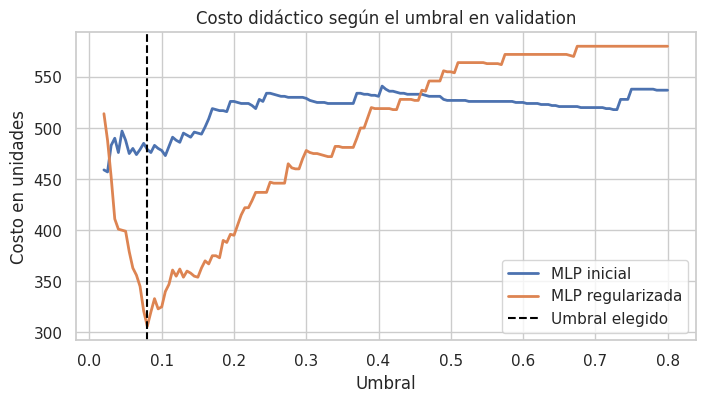

In [11]:
# Código provisto: comparación y selección usando únicamente validation
prob_inicial_val = mlp_inicial.predict(X_val_s, verbose=0).ravel()
prob_regularizada_val = mlp_regularizada.predict(X_val_s, verbose=0).ravel()

umbral_inicial, tabla_u_i = buscar_umbral_costo(y_val, prob_inicial_val)
umbral_regularizada, tabla_u_r = buscar_umbral_costo(y_val, prob_regularizada_val)

resultado_inicial_val = metricas_binarias(
    y_val, prob_inicial_val, umbral_inicial
)
resultado_regularizada_val = metricas_binarias(
    y_val, prob_regularizada_val, umbral_regularizada
)

comparacion_val = pd.DataFrame([
    {"modelo": "DummyClassifier", **resultado_dummy_val},
    {"modelo": "MLP inicial", **resultado_inicial_val},
    {"modelo": "MLP regularizada", **resultado_regularizada_val},
]).set_index("modelo")

columnas = [
    "umbral", "accuracy", "precision", "recall", "f1", "pr_auc",
    "fp", "fn", "costo_unidades"
]
display(comparacion_val[columnas].round(3))

candidatos_mlp = comparacion_val.loc[["MLP inicial", "MLP regularizada"]]
nombre_modelo_final = candidatos_mlp.sort_values(
    ["costo_unidades", "recall"], ascending=[True, False]
).index[0]

if nombre_modelo_final == "MLP inicial":
    modelo_final = mlp_inicial
    umbral_final = umbral_inicial
else:
    modelo_final = mlp_regularizada
    umbral_final = umbral_regularizada

print("Modelo congelado:", nombre_modelo_final)
print("Umbral congelado:", round(umbral_final, 3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    tabla_u_i.sort_values("umbral")["umbral"],
    tabla_u_i.sort_values("umbral")["costo_unidades"],
    label="MLP inicial",
    linewidth=2,
)
ax.plot(
    tabla_u_r.sort_values("umbral")["umbral"],
    tabla_u_r.sort_values("umbral")["costo_unidades"],
    label="MLP regularizada",
    linewidth=2,
)
ax.axvline(umbral_final, color="black", linestyle="--", label="Umbral elegido")
ax.set_title("Costo didáctico según el umbral en validation")
ax.set_xlabel("Umbral")
ax.set_ylabel("Costo en unidades")
ax.legend()
plt.show()

### Interpretación 7 - Selección con validation

1. ¿Qué modelo y qué umbral quedaron seleccionados?
2. ¿La opción seleccionada mejora al baseline? Comparen costo, recall, precision y PR-AUC.
3. Expliquen el intercambio entre falsos negativos y falsos positivos al bajar el umbral.
4. ¿Por qué esta decisión debe quedar congelada antes de abrir test?

### Respuesta del grupo

**Respuesta 1.** Se seleccionó y congeló la **MLP regularizada** con un umbral de **0,08**.

**Respuesta 2.** Sí, supera al baseline. En *validation*, el costo baja de 580 a 306 unidades; el *recall* sube de 0,000 a 0,707; la *precision* pasa de 0,000 a 0,232; y la PR-AUC aumenta de 0,072 a 0,309. La MLP produce 17 FN y 136 FP, mientras el baseline deja 58 FN.

**Respuesta 3.** Al bajar el umbral es más fácil clasificar un caso como riesgo. Esto reduce los falsos negativos y aumenta el *recall*, pero eleva los falsos positivos y normalmente reduce la *precision*. El intercambio es razonable porque un FN cuesta 10 veces más que un FP.

**Respuesta 4.** La decisión debe quedar congelada antes de abrir *test* para preservar una evaluación independiente. Si se cambiara el modelo o el umbral después de observar *test*, este conjunto se convertiría en otro medio de ajuste y el resultado final sería optimista.

## 9. Test sellado

La siguiente celda evalúa una sola vez el modelo y el umbral ya congelados. Si intenta ejecutarla nuevamente en la misma sesión, el notebook mostrará una advertencia.

,umbral,accuracy,precision,recall,f1,pr_auc,fp,fn,costo_unidades
modelo,,,,,,,,,
DummyClassifier,0.50,0.926,0.000,0.000,0.000,0.074,0,59,590
MLP regularizada,0.08,0.782,0.205,0.678,0.315,0.316,155,19,345


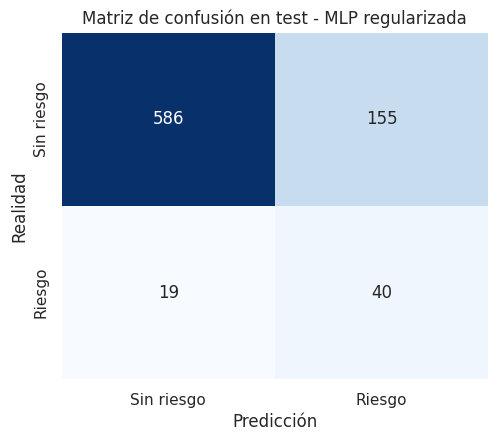

,precision,recall,f1-score,support
Sin riesgo,0.969,0.791,0.871,741.000
Riesgo,0.205,0.678,0.315,59.000
accuracy,0.782,0.782,0.782,0.782
macro avg,0.587,0.734,0.593,800.000
weighted avg,0.912,0.782,0.830,800.000


In [12]:
# Código provisto: apertura única del conjunto de test
if globals().get("_TEST_ABIERTO", False):
    raise RuntimeError(
        "El conjunto de test ya fue abierto en esta sesión. "
        "Reinicie el entorno para repetir todo el experimento."
    )

_TEST_ABIERTO = True

prob_final_test = modelo_final.predict(X_test_s, verbose=0).ravel()
resultado_final_test = metricas_binarias(
    y_test, prob_final_test, umbral_final
)

prob_dummy_test = dummy.predict_proba(X_test_s)[:, 1]
resultado_dummy_test = metricas_binarias(
    y_test, prob_dummy_test, umbral=0.5
)

comparacion_test = pd.DataFrame([
    {"modelo": "DummyClassifier", **resultado_dummy_test},
    {"modelo": nombre_modelo_final, **resultado_final_test},
]).set_index("modelo")

display(comparacion_test[columnas].round(3))

graficar_matriz(
    y_test,
    prob_final_test,
    umbral_final,
    f"Matriz de confusión en test - {nombre_modelo_final}",
)

pred_final_test = (prob_final_test >= umbral_final).astype(int)
reporte_test = pd.DataFrame(
    classification_report(
        y_test,
        pred_final_test,
        target_names=["Sin riesgo", "Riesgo"],
        output_dict=True,
        zero_division=0,
    )
).T

display(reporte_test.round(3))

### Interpretación 8 - Resultado final en datos no vistos

1. Lea la matriz de confusión: ¿cuántos FP y FN produjo el modelo?
2. ¿Cuál de esos errores tiene mayor impacto bajo los costos establecidos?
3. Comparen validation y test. ¿El desempeño parece consistente o existe una caída relevante?
4. ¿Recomendarían descartar el modelo, continuar la investigación o realizar un piloto controlado? Justifiquen.

### Respuesta del grupo

**Respuesta 1.** En *test*, la MLP regularizada produjo **155 falsos positivos y 19 falsos negativos**. Además, identificó correctamente 40 de los 59 casos de riesgo.

**Respuesta 2.** Los falsos negativos tienen mayor impacto individual porque cada FN cuesta 10 unidades, mientras cada FP cuesta 1. Los FN aportan 190 unidades y los FP 155, para un costo total de 345.

**Respuesta 3.** El desempeño es razonablemente consistente. De *validation* a *test*, el *recall* pasa de 0,707 a 0,678; la *precision* de 0,232 a 0,205; la *accuracy* de 0,809 a 0,782; y el costo de 306 a 345. La PR-AUC cambia de 0,309 a 0,316. Hay una caída moderada, pero no un colapso.

**Respuesta 4.** Recomendamos continuar la investigación y realizar un **piloto controlado**, con supervisión humana y seguimiento de falsas alarmas y fallas omitidas. No recomendamos todavía un despliegue automático.

## 10. Conclusión técnica

Redacten entre 150 y 250 palabras e incluyan:

- el modelo y el umbral seleccionados;
- la comparación contra el baseline;
- la lectura de FP y FN según su costo;
- las principales limitaciones del experimento;
- una recomendación: descartar, continuar investigación o piloto controlado.

### Conclusión final del grupo

El modelo seleccionado con *validation* fue la **MLP regularizada** y se congeló un umbral de **0,08**. En ese conjunto obtuvo *recall* de 0,707, *precision* de 0,232, PR-AUC de 0,309 y un costo de 306 unidades, superando al `DummyClassifier`, cuyo *recall* fue 0,000, PR-AUC 0,072 y costo 580. La evaluación única en *test* confirmó una mejora relevante: costo de 345 frente a 590 del baseline, *recall* de 0,678 y PR-AUC de 0,316. La matriz de confusión registró 155 falsos positivos y 19 falsos negativos. Aunque los FP son más numerosos, los FN son el error más crítico porque cuestan 10 unidades cada uno; aportan 190 de las 345 unidades de costo.

Las principales limitaciones son el uso de datos sintéticos, una clase positiva pequeña, una sola partición aleatoria, costos didácticos no validados por una empresa y ausencia de pruebas de deriva, calibración, robustez y explicabilidad. Además, la *precision* de 0,205 implica numerosas falsas alarmas que podrían generar fatiga operativa. Aun así, el desempeño entre *validation* y *test* es relativamente consistente y no muestra una caída severa. Recomendamos realizar un **piloto controlado**, sin automatizar decisiones críticas, con revisión humana, monitoreo continuo y validación posterior con datos industriales reales antes de considerar un despliegue.

## Checklist de entrega

- [ ] Registramos el número del grupo y los nombres de todos los integrantes.
- [ ] Ejecutamos todas las celdas en orden sin modificar el código provisto.
- [ ] Dejamos visibles las tablas, curvas y matriz de confusión.
- [ ] Respondimos las ocho secciones de interpretación en Markdown.
- [ ] Sustentamos las respuestas con valores o evidencia de las salidas.
- [ ] Todos los integrantes participaron y los roles se rotaron.
- [ ] No utilizamos test para cambiar el modelo o el umbral.
- [ ] La conclusión distingue evidencia, inferencia y limitaciones.

## Registro breve de participación

Completen una fila por integrante. Describan un aporte concreto realizado durante la discusión; no asignen las preguntas por separado.

| Integrante | Rol o roles asumidos | Aporte concreto a la interpretación |
|---|---|---|
|  |  |  |
|  |  |  |
|  |  |  |
|  |  |  |
|  |  |  |

## Fuentes oficiales

- [Keras EarlyStopping](https://keras.io/api/callbacks/early_stopping/)
- [Scikit-learn: common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)
- [Scikit-learn: DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)